# ML Lab 2

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [ ]:
import pandas as pd

df = pd.read_csv("Iris.csv")

print("missing values (True = missing):")
print(df.isnull())

print("\nnot null values (True = present):")
print(df.notnull())

print("\ntotal missing values in each column:")
print(df.isnull().sum())

missing values (True = missing):
        Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm  Species
0    False          False         False          False         False    False
1    False          False         False          False         False    False
2    False          False         False          False         False    False
3    False          False         False          False         False    False
4    False          False         False          False         False    False
..     ...            ...           ...            ...           ...      ...
145  False          False         False          False         False    False
146  False          False         False          False         False    False
147  False          False         False          False         False    False
148  False          False         False          False         False    False
149  False          False         False          False         False    False

[150 rows x 6 columns]

not nu

In [ ]:
df = pd.read_csv("Iris.csv")

print("Original dataset size:", df.shape)
clean_df = df.dropna()
print("Dataset size after removing missing rows:", clean_df.shape)


Original dataset size: (150, 6)
Dataset size after removing missing rows: (150, 6)


In [ ]:
import numpy as np

# introduce some missing values for demo
df.loc[2, "SepalLengthCm"] = np.nan
df.loc[5, "Species"] = np.nan

# fill numerical with mean
df["SepalLengthCm"].fillna(df["SepalLengthCm"].mean(), inplace=True)

# fill categorical with constant
df["Species"].fillna("Unknown", inplace=True)

print(df.head(10))


   Id  SepalLengthCm  SepalWidthCm  PetalLengthCm  PetalWidthCm      Species
0   1       5.100000           3.5            1.4           0.2  Iris-setosa
1   2       4.900000           3.0            1.4           0.2  Iris-setosa
2   3       5.851007           3.2            1.3           0.2  Iris-setosa
3   4       4.600000           3.1            1.5           0.2  Iris-setosa
4   5       5.000000           3.6            1.4           0.2  Iris-setosa
5   6       5.400000           3.9            1.7           0.4      Unknown
6   7       4.600000           3.4            1.4           0.3  Iris-setosa
7   8       5.000000           3.4            1.5           0.2  Iris-setosa
8   9       4.400000           2.9            1.4           0.2  Iris-setosa
9  10       4.900000           3.1            1.5           0.1  Iris-setosa


/tmp/ipython-input-2494405666.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["SepalLengthCm"].fillna(df["SepalLengthCm"].mean(), inplace=True)
/tmp/ipython-input-2494405666.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, i

In [ ]:
print("Before conversion:")
print(df.dtypes)

print("\nAfter conversion:")
print(df.dtypes)

Before conversion:
Id                object
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object

After conversion:
Id                object
SepalLengthCm    float64
SepalWidthCm     float64
PetalLengthCm    float64
PetalWidthCm     float64
Species           object
dtype: object


In [ ]:
df = df.rename(columns={
    "SepalLengthCm": "Sepal_Length",
    "SepalWidthCm": "Sepal_Width",
    "PetalLengthCm": "Petal_Length",
    "PetalWidthCm": "Petal_Width"
})

print(df.head())

  Id  Sepal_Length  Sepal_Width  Petal_Length  Petal_Width      Species
0  1      5.100000          3.5           1.4          0.2  Iris-setosa
1  2      4.900000          3.0           1.4          0.2  Iris-setosa
2  3      5.851007          3.2           1.3          0.2  Iris-setosa
3  4      4.600000          3.1           1.5          0.2  Iris-setosa
4  5      5.000000          3.6           1.4          0.2  Iris-setosa


In [ ]:
# create inconsistency for demo
df.loc[0, "Species"] = "setosa "

print("Before correction:")
print(df["Species"].unique())

# fix using replace
df["Species"] = df["Species"].replace({
    "setosa ": "setosa"
})

print("\nAfter correction:")
print(df["Species"].unique())

Before correction:
['setosa ' 'Iris-setosa' 'Unknown' 'Iris-versicolor' 'Iris-virginica']

After correction:
['setosa' 'Iris-setosa' 'Unknown' 'Iris-versicolor' 'Iris-virginica']


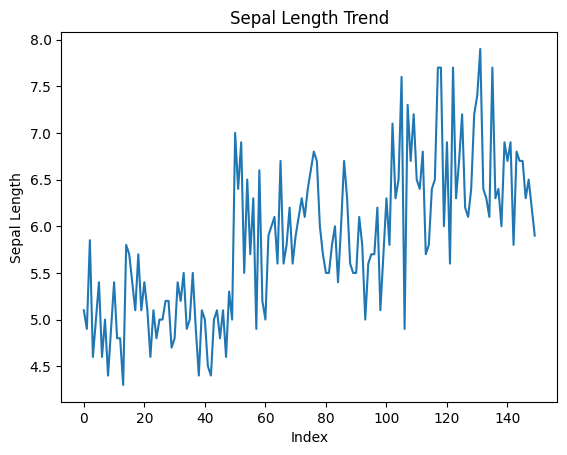

In [ ]:
import matplotlib.pyplot as plt

plt.plot(df["Sepal_Length"])
plt.title("Sepal Length Trend")
plt.xlabel("Index")
plt.ylabel("Sepal Length")
plt.show()

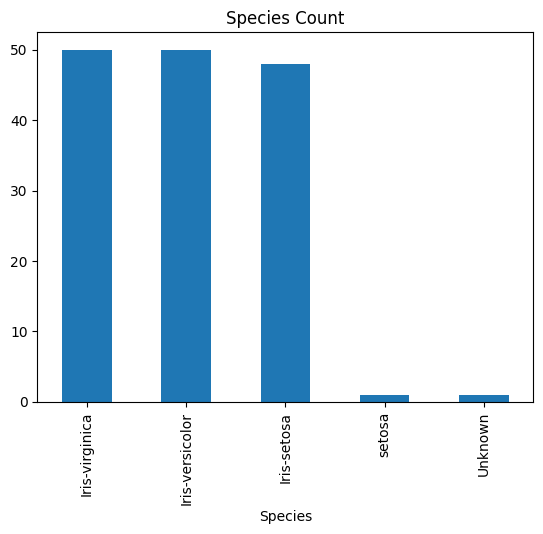

In [ ]:
# bar plot (species count)
df["Species"].value_counts().plot(kind="bar")
plt.title("Species Count")
plt.show()

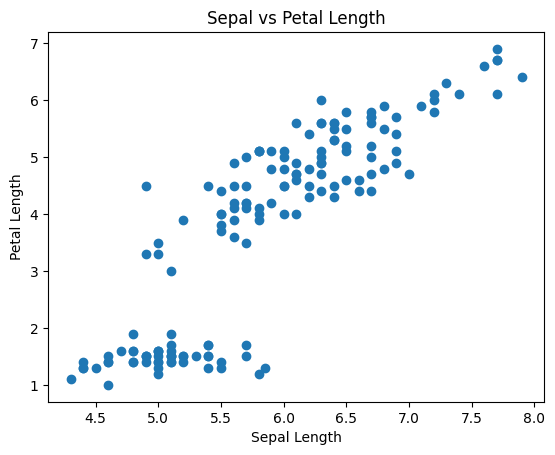

Interpretation: Strong positive relationship — larger sepals tend to have larger petals.


In [ ]:
plt.scatter(df["Sepal_Length"], df["Petal_Length"])
plt.xlabel("Sepal Length")
plt.ylabel("Petal Length")
plt.title("Sepal vs Petal Length")
plt.show()

print("Interpretation: Strong positive relationship — larger sepals tend to have larger petals.")

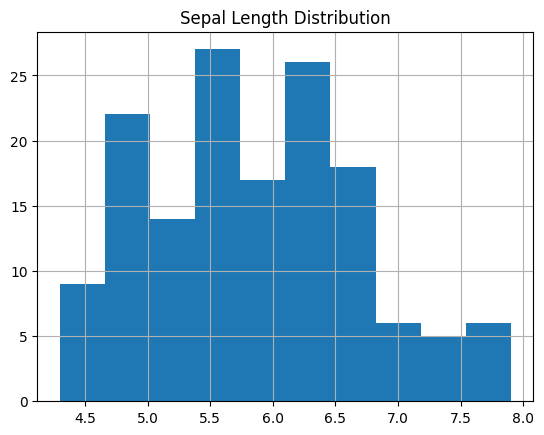

Skewness: 0.31099142943464386


In [ ]:
df["Sepal_Length"].hist()
plt.title("Sepal Length Distribution")
plt.show()

print("Skewness:", df["Sepal_Length"].skew())

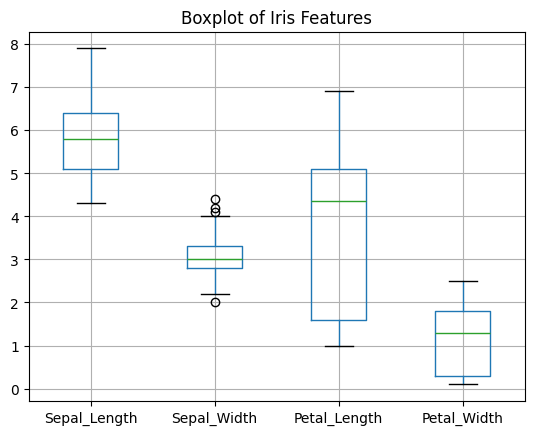

In [ ]:
df.boxplot(column=[
    "Sepal_Length",
    "Sepal_Width",
    "Petal_Length",
    "Petal_Width"
])
plt.title("Boxplot of Iris Features")
plt.show()